# Final Project: Weather and Daily Activity

## Project Overview

This project investigates how weather conditions influence daily productivity-related behavior.

To explore this question, I use two datasets:

- A **wearable activity dataset (Norway, 2019–2020)** containing daily physical activity records from 113 participants (e.g., steps, activity levels, sedentary time)
- A **weather dataset from Open-Meteo**, including daily variables such as temperature, precipitation, and cloud cover for the same time period

The goal is to compare these two datasets by aligning them on a daily basis and analyzing how weather conditions relate to changes in physical activity, which serves as a proxy for productivity.

Before merging the datasets, I first clean and restructure the activity data to:
- select relevant variables,
- standardize column names,
- and convert date formats.

This ensures that both datasets share a consistent structure and can be accurately merged for analysis.

## Research Questions

This project focuses on four main data-based questions:

1. How is daily temperature related to average daily steps?
2. Do low-, medium-, and high-activity participants respond differently to temperature?
3. Are precipitation days associated with lower daily activity?
4. Is cloud cover associated with changes in daily steps?

Together, these questions help evaluate whether weather conditions are meaningfully related to productivity-related behavior, using physical activity as a measurable proxy.

## Step 1. Load the Activity Dataset

In this step, I load the raw wearable activity dataset. This dataset contains daily activity records from multiple participants using Garmin or Fitbit devices.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
activity_raw = pd.read_csv('/content/data raw (1).csv')
activity_raw.head()

,ID\tDate\tSteps\tTEE\tAEE\tSedentary\tLPA\tMPA\tVPA\tNonWear\tProvider
0,1\t03.09.2019\t1208\t2375\t72\t0\t0\t10\t0\t0\...
1,1\t04.09.2019\t6784\t2713\t410\t0\t0\t0\t0\t0\...
2,1\t05.09.2019\t6470\t2685\t382\t0\t0\t0\t0\t0\...
3,1\t06.09.2019\t10042\t2817\t514\t0\t0\t0\t0\t0...
4,1\t07.09.2019\t6301\t4289\t1986\t0\t0\t21\t137...


##(Fix). Load the Activity Dataset Correctly

The dataset is tab-separated, so I specify the separator to correctly split columns.

In [ ]:
activity_raw = pd.read_csv("/content/data raw (1).csv", sep="\t")

activity_raw.head()

,ID,Date,Steps,TEE,AEE,Sedentary,LPA,MPA,VPA,NonWear,Provider
0,1,03.09.2019,1208,2375,72,0,0,10,0,0,Garmin
1,1,04.09.2019,6784,2713,410,0,0,0,0,0,Garmin
2,1,05.09.2019,6470,2685,382,0,0,0,0,0,Garmin
3,1,06.09.2019,10042,2817,514,0,0,0,0,0,Garmin
4,1,07.09.2019,6301,4289,1986,0,0,21,137,0,Garmin


## Step 2. Check the Dataset Structure

Before cleaning the data, I first check the column names, data types, and missing values. This helps me understand what needs to be renamed, removed, or fixed.

In [ ]:
activity_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72001 entries, 0 to 72000
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         72001 non-null  int64 
 1   Date       72001 non-null  object
 2   Steps      72001 non-null  int64 
 3   TEE        72001 non-null  int64 
 4   AEE        72001 non-null  int64 
 5   Sedentary  72001 non-null  int64 
 6   LPA        72001 non-null  int64 
 7   MPA        72001 non-null  int64 
 8   VPA        72001 non-null  int64 
 9   NonWear    72001 non-null  int64 
 10  Provider   72001 non-null  object
dtypes: int64(9), object(2)
memory usage: 6.0+ MB


In [ ]:
activity_raw.isna().sum()

,0
ID,0
Date,0
Steps,0
TEE,0
AEE,0
Sedentary,0
LPA,0
MPA,0
VPA,0
NonWear,0


## Step 3. Clean Column Names and Select Relevant Variables

The raw dataset contains technical column names and unnecessary variables.
In this step, I rename columns to be more readable and keep only the variables relevant to productivity analysis.

In [ ]:
activity_raw.columns

Index(['ID', 'Date', 'Steps', 'TEE', 'AEE', 'Sedentary', 'LPA', 'MPA', 'VPA',
       'NonWear', 'Provider'],
      dtype='object')

In [ ]:
activity = activity_raw.rename(columns={
    'ID': 'participant_id',
    'Date': 'date',
    'Steps': 'steps',
    'TEE': 'total_energy',
    'AEE': 'activity_energy',
    'Sedentary': 'sedentary_minutes',
    'LPA': 'light_activity_minutes',
    'MPA': 'moderate_activity_minutes',
    'VPA': 'vigorous_activity_minutes',
    'NonWear': 'nonwear_minutes',
    'Provider': 'device'
})

I keep only variables directly related to physical activity behavior.
Energy variables and non-wear time are removed because they are less interpretable or unreliable.

In [ ]:
activity = activity[[
    'participant_id',
    'date',
    'steps',
    'light_activity_minutes',
    'moderate_activity_minutes',
    'vigorous_activity_minutes',
    'sedentary_minutes'
]]

In [ ]:
activity.head()

,participant_id,date,steps,light_activity_minutes,moderate_activity_minutes,vigorous_activity_minutes,sedentary_minutes
0,1,03.09.2019,1208,0,10,0,0
1,1,04.09.2019,6784,0,0,0,0
2,1,05.09.2019,6470,0,0,0,0
3,1,06.09.2019,10042,0,0,0,0
4,1,07.09.2019,6301,0,21,137,0


## Step 4. Convert Date to Datetime Format

The activity dataset uses a different date format (dd.mm.yyyy).  
I convert it into a standard datetime format to prepare for merging with the weather dataset.

In [ ]:
activity['date'] = pd.to_datetime(activity['date'], format='%d.%m.%Y')

activity.head()

,participant_id,date,steps,light_activity_minutes,moderate_activity_minutes,vigorous_activity_minutes,sedentary_minutes
0,1,2019-09-03,1208,0,10,0,0
1,1,2019-09-04,6784,0,0,0,0
2,1,2019-09-05,6470,0,0,0,0
3,1,2019-09-06,10042,0,0,0,0
4,1,2019-09-07,6301,0,21,137,0


In [ ]:
type(activity['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

## Step 5. Segment Participants by Activity Level

Instead of averaging all participants together, I divide participants into low-, medium-, and high-activity groups based on their average daily steps. This allows me to compare whether weather affects different types of participants differently.

In [ ]:
participant_steps = activity.groupby('participant_id')['steps'].mean().reset_index()

participant_steps['activity_group'] = pd.qcut(
    participant_steps['steps'],
    q=3,
    labels=['low_activity', 'medium_activity', 'high_activity']
)

participant_steps.head()

,participant_id,steps,activity_group
0,1,8968.850325,medium_activity
1,2,13336.542069,high_activity
2,3,10681.497561,medium_activity
3,4,11290.431877,high_activity
4,5,7576.908345,low_activity


I use `qcut()` to divide participants into three equally sized groups based on average daily steps:

- low_activity
- medium_activity
- high_activity


This creates participant segments that can later be compared separately in the analysis.

This table shows each participant’s average daily step count and their assigned activity group.

In [ ]:
participant_steps['activity_group'].value_counts()

,count
activity_group,
low_activity,38
high_activity,38
medium_activity,37


## Step 6. Load and Prepare the Weather Dataset

In this step, I load the weather dataset and convert the date column into a datetime format to match the activity dataset.

In [ ]:
weather = pd.read_csv("/content/open-meteo-62.00N10.01E801m (1).csv")

weather.head()

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,61.998028,10.006897,801.0,0,GMT,GMT
1,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%)
2,2019-01-01T00:00,-2.8,77,0.00,0.00,33
3,2019-01-01T01:00,-2.7,76,0.00,0.00,79
4,2019-01-01T02:00,-7.0,84,0.10,0.00,97


In [ ]:
weather.columns

Index(['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone',
       'timezone_abbreviation'],
      dtype='object')

##(Fix). Load Weather Data with Correct Format

The weather dataset contains metadata in the first row and actual column names in the second row.

I reload the dataset by skipping the first row so that the correct header is used.

In [ ]:
weather = pd.read_csv("/content/open-meteo-62.00N10.01E801m (1).csv", skiprows=2)

weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%)
0,2019-01-01T00:00,-2.8,77,0.0,0.0,33
1,2019-01-01T01:00,-2.7,76,0.0,0.0,79
2,2019-01-01T02:00,-7.0,84,0.1,0.0,97
3,2019-01-01T03:00,-5.8,83,0.1,0.0,88
4,2019-01-01T04:00,-5.9,83,0.1,0.0,76


## Step 7. Convert Time and Aggregate Weather Data

The weather dataset is recorded hourly, while the activity dataset is daily.

To make them compatible, I convert the time column to datetime, extract the date, and compute daily averages for weather variables.

In [ ]:
weather['time'] = pd.to_datetime(weather['time'])

In [ ]:
weather['date'] = weather['time'].dt.date

In [ ]:
daily_weather = weather.groupby('date').mean(numeric_only=True).reset_index()

daily_weather.head()

,date,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%)
0,2019-01-01,-3.104167,78.250000,0.350000,0.0000,88.750000
1,2019-01-02,-4.125000,77.958333,0.037500,0.0000,96.125000
2,2019-01-03,0.200000,85.125000,0.000000,0.0000,99.625000
3,2019-01-04,3.004167,83.333333,0.020833,0.0125,76.166667
4,2019-01-05,1.683333,93.250000,0.000000,0.0000,94.000000


In [ ]:
daily_weather.shape

(731, 6)

## Step 8. Check Weather Dataset Structure(A)

Before merging the weather data with the activity data, I first check the structure of the daily weather dataset. This helps confirm the number of rows, available columns, date range, and whether there are missing values.

In [ ]:
daily_weather.head()

,date,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%)
0,2019-01-01,-3.104167,78.250000,0.350000,0.0000,88.750000
1,2019-01-02,-4.125000,77.958333,0.037500,0.0000,96.125000
2,2019-01-03,0.200000,85.125000,0.000000,0.0000,99.625000
3,2019-01-04,3.004167,83.333333,0.020833,0.0125,76.166667
4,2019-01-05,1.683333,93.250000,0.000000,0.0000,94.000000


In [ ]:
daily_weather.shape

(731, 6)

In [ ]:
daily_weather.columns

Index(['date', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'rain (mm)', 'cloud_cover (%)'],
      dtype='object')

In [ ]:
daily_weather['date'] = pd.to_datetime(daily_weather['date'])

daily_weather['date'].min(), daily_weather['date'].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2020-12-31 00:00:00'))

In [ ]:
daily_weather.isna().sum()

,0
date,0
temperature_2m (°C),0
relative_humidity_2m (%),0
precipitation (mm),0
rain (mm),0
cloud_cover (%),0


## Step 8. Select Relevant Weather Variables(B)

For this project, I focus on weather variables that are likely to affect daily activity behavior: temperature, precipitation, and cloud cover. These variables are simple to interpret and can be compared with daily activity patterns.

In [ ]:
weather_selected = daily_weather[[
    'date',
    'temperature_2m (°C)',
    'precipitation (mm)',
    'cloud_cover (%)'
]].copy()

weather_selected = weather_selected.rename(columns={
    'temperature_2m (°C)': 'temperature',
    'precipitation (mm)': 'precipitation',
    'cloud_cover (%)': 'cloud_cover'
})

weather_selected.head()

,date,temperature,precipitation,cloud_cover
0,2019-01-01,-3.104167,0.350000,88.750000
1,2019-01-02,-4.125000,0.037500,96.125000
2,2019-01-03,0.200000,0.000000,99.625000
3,2019-01-04,3.004167,0.020833,76.166667
4,2019-01-05,1.683333,0.000000,94.000000


## Step 8. Temperature Trend(C)

Instead of plotting every daily temperature value, I use monthly average temperature to make the seasonal pattern easier to see. This helps show whether the weather data captures meaningful changes across the year before it is merged with the activity data.

In [ ]:
import matplotlib.pyplot as plt

monthly_temperature = weather_selected.copy()
monthly_temperature['month'] = monthly_temperature['date'].dt.to_period('M').dt.to_timestamp()

monthly_temperature = monthly_temperature.groupby('month')['temperature'].mean().reset_index()

monthly_temperature.head()

,month,temperature
0,2019-01-01,-7.947312
1,2019-02-01,-4.872173
2,2019-03-01,-5.067473
3,2019-04-01,1.840139
4,2019-05-01,4.136022


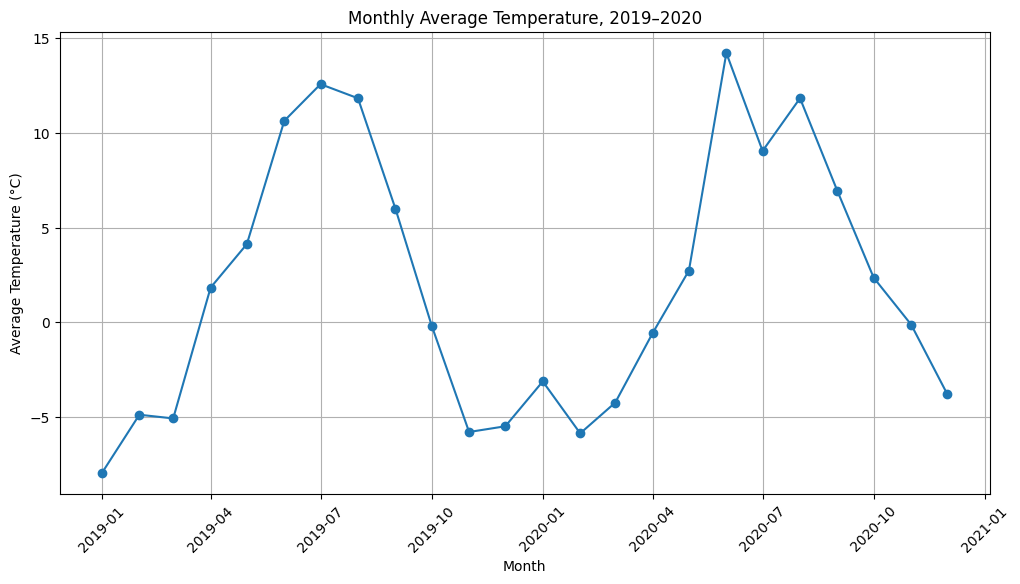

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_temperature['month'],
    monthly_temperature['temperature'],
    marker='o'
)

plt.title('Monthly Average Temperature, 2019–2020')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The monthly temperature pattern shows clear seasonal variation. Temperatures are lowest during the winter months and highest during the summer months. This confirms that temperature changes meaningfully over time, so it is a useful weather variable to compare with activity behavior.

## Step 8. Precipitation Distribution(D)

Next, I examine the distribution of daily precipitation. A histogram is useful here because precipitation is usually unevenly distributed, with many dry or low-precipitation days and fewer high-precipitation days.

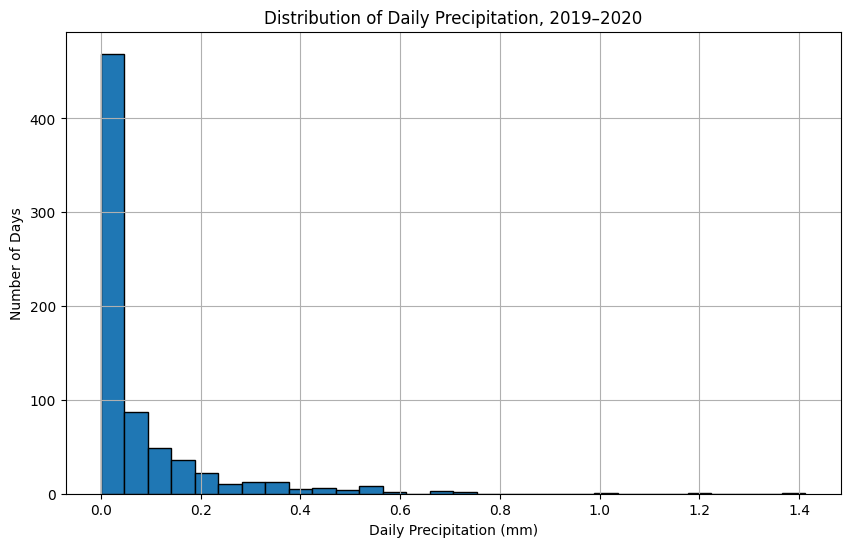

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    weather_selected['precipitation'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Daily Precipitation, 2019–2020')
plt.xlabel('Daily Precipitation (mm)')
plt.ylabel('Number of Days')
plt.grid(True)
plt.show()

I also calculate the percentage of measurable precipitation days. Instead of counting every value greater than 0, I define a precipitation day as a day with at least 0.1 mm of precipitation. This avoids counting very tiny trace amounts as rainy days.

In [ ]:
precipitation_days = weather_selected['precipitation'] >= 0.1

precipitation_day_percentage = precipitation_days.mean() * 100

print(f"Precipitation-day percentage: {precipitation_day_percentage:.1f}%")

Precipitation-day percentage: 23.4%


The precipitation histogram shows that most days had very low precipitation, while only a small number of days had higher precipitation. This means the precipitation data is strongly right-skewed. Using a 0.1 mm threshold, about 23.4% of days had measurable precipitation. This is a more realistic measure because it avoids counting tiny trace amounts as meaningful rainy days.

## Step 8. Cloud Cover Distribution(E)

Finally, I examine the distribution of daily cloud cover. Cloud cover may affect outdoor activity because very cloudy days can feel different from clear days, even when there is no precipitation. This step helps check whether cloud cover has enough variation to be useful in the analysis.

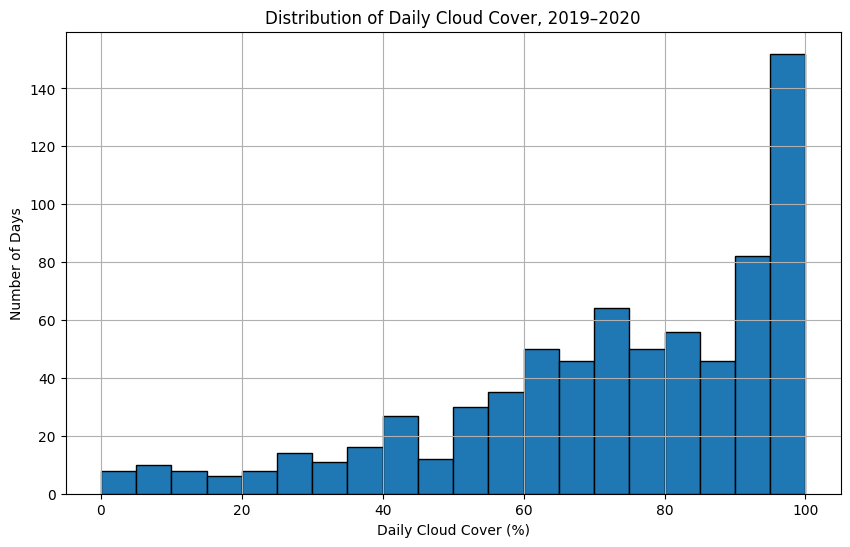

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    weather_selected['cloud_cover'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Daily Cloud Cover, 2019–2020')
plt.xlabel('Daily Cloud Cover (%)')
plt.ylabel('Number of Days')
plt.grid(True)
plt.show()

I also summarize cloud cover numerically to see the average level of cloudiness and how widely it varies.

In [ ]:
weather_selected['cloud_cover'].describe()

,cloud_cover
count,731.000000
mean,72.702234
std,24.167376
min,0.000000
25%,59.895833
50%,77.166667
75%,93.666667
max,100.000000


For a simple summary, I define a cloudy day as a day with at least 75% cloud cover.

In [ ]:
cloudy_days = weather_selected['cloud_cover'] >= 75

cloudy_day_percentage = cloudy_days.mean() * 100

print(f"Cloudy-day percentage: {cloudy_day_percentage:.1f}%")

Cloudy-day percentage: 52.8%


The cloud cover data shows that this location was often cloudy. The average cloud cover was about 72.7%, and the median was about 77.2%. Using 75% cloud cover as a simple threshold, about 52.8% of days were cloudy. This means cloud cover has useful variation and may be worth comparing with activity behavior.

## Step 9A. Add Activity Group to Daily Activity Data

To follow the professor's suggestion, I assign each participant to a low-, medium-, or high-activity group based on their average daily steps. Then I add this group label back to the daily activity dataset so that I can analyze daily behavior separately for each group.

In [ ]:
activity_grouped = activity.merge(
    participant_steps[['participant_id', 'activity_group']],
    on='participant_id',
    how='left'
)

activity_grouped.head()

,participant_id,date,steps,light_activity_minutes,moderate_activity_minutes,vigorous_activity_minutes,sedentary_minutes,activity_group
0,1,2019-09-03,1208,0,10,0,0,medium_activity
1,1,2019-09-04,6784,0,0,0,0,medium_activity
2,1,2019-09-05,6470,0,0,0,0,medium_activity
3,1,2019-09-06,10042,0,0,0,0,medium_activity
4,1,2019-09-07,6301,0,21,137,0,medium_activity


In [ ]:
activity_grouped['activity_group'].value_counts()

,count
activity_group,
high_activity,24556
low_activity,23754
medium_activity,23691


## Step 9B. Check Average Activity by Group

Before comparing activity with weather, I first check whether the three activity groups actually differ in their daily behavior. This helps confirm that the grouping method created meaningful participant segments.

In [ ]:
group_summary = activity_grouped.groupby('activity_group')[[
    'steps',
    'light_activity_minutes',
    'moderate_activity_minutes',
    'vigorous_activity_minutes',
    'sedentary_minutes'
]].mean()

group_summary

/tmp/ipykernel_4679/4148908476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_summary = activity_grouped.groupby('activity_group')[[


,steps,light_activity_minutes,moderate_activity_minutes,vigorous_activity_minutes,sedentary_minutes
activity_group,,,,,
low_activity,6348.836238,85.919214,13.121411,16.049423,319.153195
medium_activity,9406.165337,92.350851,16.023511,23.833270,248.830484
high_activity,13015.281194,67.878523,19.619238,37.647866,180.770565


## Step 9C. Visualize Average Steps by Group

I visualize average daily steps for each activity group to confirm that the low-, medium-, and high-activity groups are clearly separated.

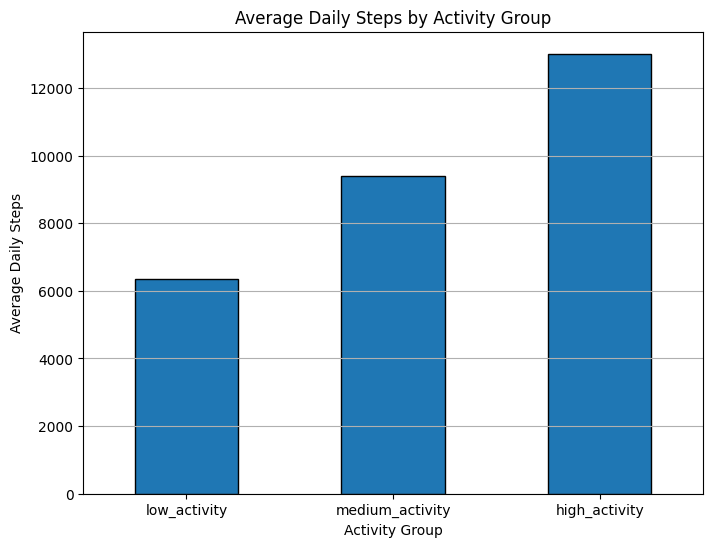

In [ ]:
plt.figure(figsize=(8, 6))

group_summary['steps'].plot(kind='bar', edgecolor='black')

plt.title('Average Daily Steps by Activity Group')
plt.xlabel('Activity Group')
plt.ylabel('Average Daily Steps')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

The activity groups are clearly separated by average daily steps. The low-activity group averaged about 6,349 steps per day, the medium-activity group averaged about 9,406 steps, and the high-activity group averaged about 13,015 steps. This confirms that grouping participants by average steps created meaningful activity segments. The high-activity group also had more vigorous activity minutes and fewer sedentary minutes, which supports the idea that these groups represent different activity behavior patterns.

## Step 10A. Aggregate Activity by Date and Group

Before merging with weather data, I aggregate the activity data by date and activity group. This creates one daily average activity value for each group, which allows me to compare low-, medium-, and high-activity participants under the same daily weather conditions.

In [ ]:
daily_activity_by_group = activity_grouped.groupby(
    ['date', 'activity_group'],
    observed=False
)[[
    'steps',
    'light_activity_minutes',
    'moderate_activity_minutes',
    'vigorous_activity_minutes',
    'sedentary_minutes'
]].mean().reset_index()

daily_activity_by_group.head()

,date,activity_group,steps,light_activity_minutes,moderate_activity_minutes,vigorous_activity_minutes,sedentary_minutes
0,2019-01-01,low_activity,3055.807692,56.692308,11.230769,2.846154,276.269231
1,2019-01-01,medium_activity,5935.384615,60.500000,9.500000,20.884615,248.346154
2,2019-01-01,high_activity,12275.000000,74.785714,19.250000,37.821429,184.071429
3,2019-01-02,low_activity,5377.038462,61.692308,19.923077,15.500000,287.423077
4,2019-01-02,medium_activity,6420.923077,70.384615,11.576923,17.038462,237.423077


In [ ]:
daily_activity_by_group.shape

(2193, 7)

## Step 10B. Merge Activity and Weather Data

I merge the grouped daily activity data with the selected daily weather data using the date column. This creates a combined dataset where each row represents one activity group on one date, along with the weather conditions for that date.

In [ ]:
merged_data = daily_activity_by_group.merge(
    weather_selected,
    on='date',
    how='inner'
)

merged_data.head()

,date,activity_group,steps,light_activity_minutes,moderate_activity_minutes,vigorous_activity_minutes,sedentary_minutes,temperature,precipitation,cloud_cover
0,2019-01-01,low_activity,3055.807692,56.692308,11.230769,2.846154,276.269231,-3.104167,0.3500,88.750
1,2019-01-01,medium_activity,5935.384615,60.500000,9.500000,20.884615,248.346154,-3.104167,0.3500,88.750
2,2019-01-01,high_activity,12275.000000,74.785714,19.250000,37.821429,184.071429,-3.104167,0.3500,88.750
3,2019-01-02,low_activity,5377.038462,61.692308,19.923077,15.500000,287.423077,-4.125000,0.0375,96.125
4,2019-01-02,medium_activity,6420.923077,70.384615,11.576923,17.038462,237.423077,-4.125000,0.0375,96.125


In [ ]:
merged_data.shape

(2193, 10)

In [ ]:
merged_data.isna().sum()

,0
date,0
activity_group,0
steps,0
light_activity_minutes,0
moderate_activity_minutes,0
vigorous_activity_minutes,0
sedentary_minutes,0
temperature,0
precipitation,0
cloud_cover,0


## Step 10C. Check Merged Data Coverage

After merging, I check the date range and group counts to make sure the merged dataset still includes the expected time period and all three activity groups.

In [ ]:
merged_data['date'].min(), merged_data['date'].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2020-12-31 00:00:00'))

In [ ]:
merged_data['activity_group'].value_counts()

,count
activity_group,
low_activity,731
medium_activity,731
high_activity,731


The merged dataset has 2,193 rows, which matches 731 days multiplied by three activity groups. Each activity group has 731 daily records, and there are no missing values after the merge. This confirms that the weather and grouped activity data were successfully combined by date.

## Step 11A. Temperature and Steps by Activity Group

To begin analyzing the relationship between weather and activity, I compare daily temperature with average daily steps for each activity group. This helps show whether low-, medium-, and high-activity participants respond differently to warmer or colder days.

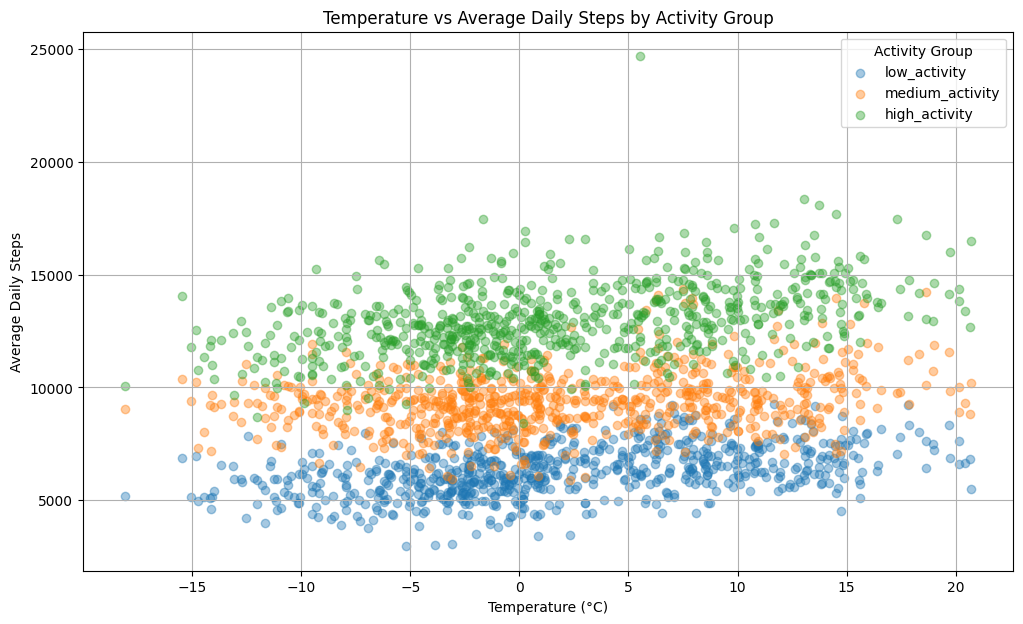

In [ ]:
plt.figure(figsize=(12, 7))

for group in merged_data['activity_group'].unique():
    group_data = merged_data[merged_data['activity_group'] == group]
    plt.scatter(
        group_data['temperature'],
        group_data['steps'],
        alpha=0.4,
        label=group
    )

plt.title('Temperature vs Average Daily Steps by Activity Group')
plt.xlabel('Temperature (°C)')
plt.ylabel('Average Daily Steps')
plt.legend(title='Activity Group')
plt.grid(True)
plt.show()

## Step 11B. Average Steps by Temperature Range

Because the scatter plot has many daily points, I also group temperature into ranges. This makes it easier to compare average steps across colder, moderate, and warmer days for each activity group.

In [ ]:
merged_data['temperature_range'] = pd.cut(
    merged_data['temperature'],
    bins=[-20, -10, 0, 10, 25],
    labels=['Very cold', 'Cold', 'Mild', 'Warm']
)

temperature_group_summary = merged_data.groupby(
    ['temperature_range', 'activity_group'],
    observed=False
)['steps'].mean().reset_index()

temperature_group_summary

,temperature_range,activity_group,steps
0,Very cold,low_activity,5604.392685
1,Very cold,medium_activity,9149.407142
2,Very cold,high_activity,11683.939432
3,Cold,low_activity,5782.674449
4,Cold,medium_activity,9067.104818
5,Cold,high_activity,12448.540267
6,Mild,low_activity,6609.723069
7,Mild,medium_activity,9524.398799
8,Mild,high_activity,13180.808699
9,Warm,low_activity,6896.258500


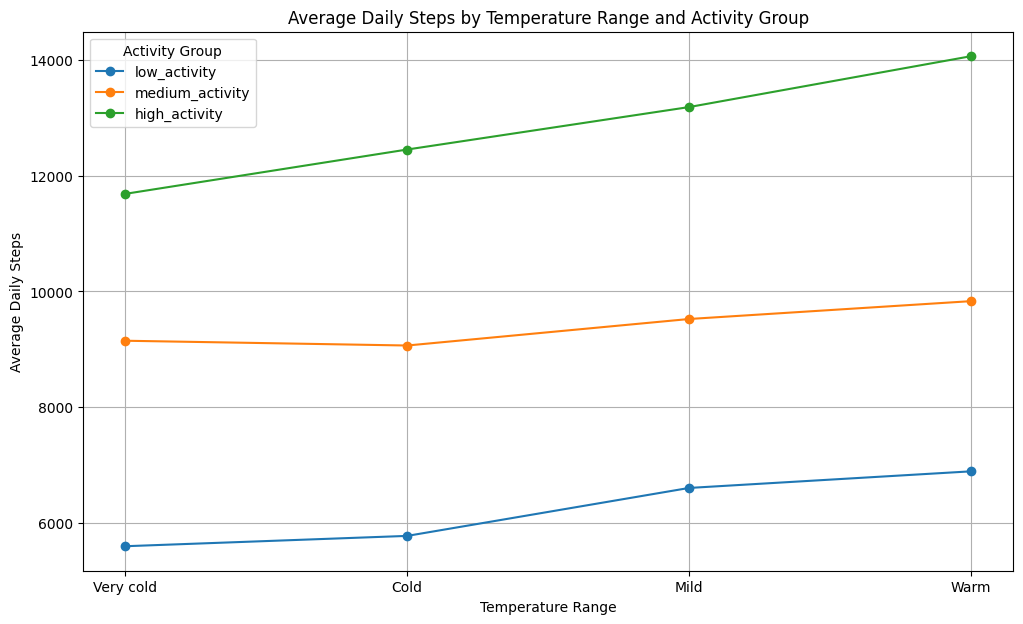

In [ ]:
plt.figure(figsize=(12, 7))

for group in temperature_group_summary['activity_group'].unique():
    group_data = temperature_group_summary[
        temperature_group_summary['activity_group'] == group
    ]
    plt.plot(
        group_data['temperature_range'].astype(str),
        group_data['steps'],
        marker='o',
        label=group
    )

plt.title('Average Daily Steps by Temperature Range and Activity Group')
plt.xlabel('Temperature Range')
plt.ylabel('Average Daily Steps')
plt.legend(title='Activity Group')
plt.grid(True)
plt.show()

The temperature analysis suggests that average daily steps tend to increase as temperature becomes warmer. This pattern appears across all three activity groups, but the groups remain clearly separated from each other. High-activity participants consistently have the most steps, while low-activity participants have the fewest. This suggests that warmer weather may be associated with more activity, but baseline activity level still matters.

## Step 11C. Precipitation and Steps by Activity Group

Next, I compare average daily steps on days with and without measurable precipitation. I use 0.1 mm as the threshold because very small trace amounts may not meaningfully affect daily activity behavior.

In [ ]:
merged_data['precipitation_category'] = merged_data['precipitation'].apply(
    lambda x: 'No measurable precipitation' if x < 0.1 else 'Measurable precipitation'
)

precipitation_group_summary = merged_data.groupby(
    ['precipitation_category', 'activity_group'],
    observed=False
)['steps'].mean().reset_index()

precipitation_group_summary

,precipitation_category,activity_group,steps
0,Measurable precipitation,low_activity,6308.670036
1,Measurable precipitation,medium_activity,9326.235380
2,Measurable precipitation,high_activity,12984.871328
3,No measurable precipitation,low_activity,6270.895263
4,No measurable precipitation,medium_activity,9395.292369
5,No measurable precipitation,high_activity,12959.588863


In [ ]:
precipitation_pivot = precipitation_group_summary.pivot(
    index='precipitation_category',
    columns='activity_group',
    values='steps'
)

precipitation_pivot

activity_group,low_activity,medium_activity,high_activity
precipitation_category,,,
Measurable precipitation,6308.670036,9326.235380,12984.871328
No measurable precipitation,6270.895263,9395.292369,12959.588863


<Figure size 1000x600 with 0 Axes>

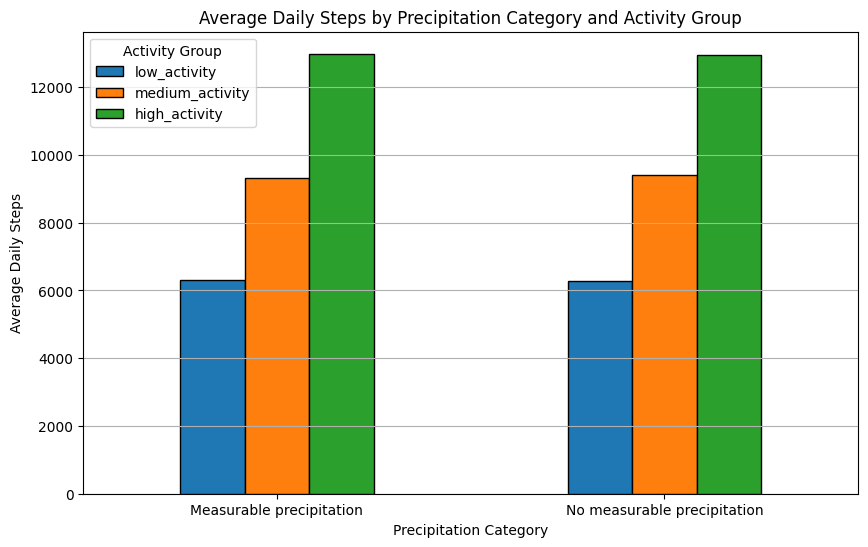

In [ ]:
plt.figure(figsize=(10, 6))

precipitation_pivot.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Average Daily Steps by Precipitation Category and Activity Group')
plt.xlabel('Precipitation Category')
plt.ylabel('Average Daily Steps')
plt.xticks(rotation=0)
plt.legend(title='Activity Group')
plt.grid(axis='y')
plt.show()

## Step 11D. Cloud Cover and Steps by Activity Group

I also compare average daily steps across different cloud cover ranges. This helps show whether participants were less active on cloudier days, even when precipitation is not directly considered.

In [ ]:
merged_data['cloud_cover_range'] = pd.cut(
    merged_data['cloud_cover'],
    bins=[-1, 50, 75, 100],
    labels=['Clear or partly cloudy', 'Cloudy', 'Very cloudy']
)

cloud_group_summary = merged_data.groupby(
    ['cloud_cover_range', 'activity_group'],
    observed=False
)['steps'].mean().reset_index()

cloud_group_summary

,cloud_cover_range,activity_group,steps
0,Clear or partly cloudy,low_activity,6290.641505
1,Clear or partly cloudy,medium_activity,9556.918816
2,Clear or partly cloudy,high_activity,13368.137424
3,Cloudy,low_activity,6476.850858
4,Cloudy,medium_activity,9597.688243
5,Cloudy,high_activity,13082.048049
6,Very cloudy,low_activity,6161.439119
7,Very cloudy,medium_activity,9196.476331
8,Very cloudy,high_activity,12772.397560


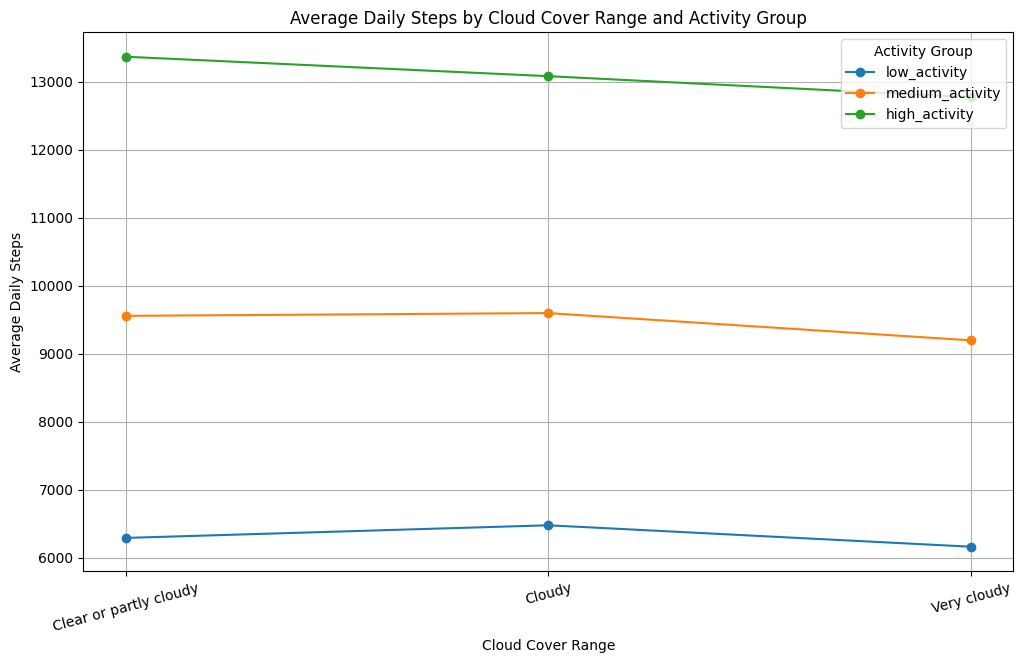

In [ ]:
plt.figure(figsize=(12, 7))

for group in cloud_group_summary['activity_group'].unique():
    group_data = cloud_group_summary[
        cloud_group_summary['activity_group'] == group
    ]
    plt.plot(
        group_data['cloud_cover_range'].astype(str),
        group_data['steps'],
        marker='o',
        label=group
    )

plt.title('Average Daily Steps by Cloud Cover Range and Activity Group')
plt.xlabel('Cloud Cover Range')
plt.ylabel('Average Daily Steps')
plt.legend(title='Activity Group')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

## Step 12A. Create Interactive Plotly Visualization

For the interactive visualization, I use Plotly to show average daily steps by temperature range and activity group. This graph is useful because it directly addresses the main research question: whether weather conditions affect low-, medium-, and high-activity participants differently.

In [ ]:
import plotly.express as px

fig = px.line(
    temperature_group_summary,
    x='temperature_range',
    y='steps',
    color='activity_group',
    markers=True,
    title='Average Daily Steps by Temperature Range and Activity Group',
    labels={
        'temperature_range': 'Temperature Range',
        'steps': 'Average Daily Steps',
        'activity_group': 'Activity Group'
    }
)

fig.update_layout(
    width=950,
    height=600,
    title_font_size=22,
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    legend_title_font_size=14,
    legend_font_size=13
)

fig.show()

## Step 12B. Save Interactive Visualization as HTML

To embed the interactive Plotly visualization on my project website, I save the figure as an HTML file. This file can be uploaded to my GitHub repository and displayed using an iframe.

In [ ]:
fig.write_html("temperature_activity_group_plotly.html")

In [ ]:
from google.colab import files

files.download("temperature_activity_group_plotly.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 12C. Interpretation of Interactive Visualization

The interactive Plotly visualization shows that average daily steps generally increase as temperature becomes warmer. This pattern appears across low-, medium-, and high-activity groups, although the groups remain clearly separated. High-activity participants consistently have the highest average steps, while low-activity participants have the lowest. Overall, this suggests that temperature is associated with daily activity, but each group's baseline activity level remains important.

## Step 12D. Interactive Daily Scatter Plot

To make the interactive visualization more detailed, I also create a Plotly scatter plot using the daily merged data. Each point represents one activity group on one day. The x-axis shows temperature, the y-axis shows average daily steps, and hovering over each point shows the date, precipitation, and cloud cover. This makes the visualization more exploratory than the summary line chart.

In [ ]:
fig_scatter = px.scatter(
    merged_data,
    x='temperature',
    y='steps',
    color='activity_group',
    opacity=0.55,
    trendline='ols',
    hover_data={
        'date': True,
        'temperature': ':.1f',
        'steps': ':.0f',
        'precipitation': ':.2f',
        'cloud_cover': ':.1f',
        'activity_group': True
    },
    title='Daily Temperature vs Average Steps by Activity Group',
    labels={
        'temperature': 'Temperature (°C)',
        'steps': 'Average Daily Steps',
        'activity_group': 'Activity Group',
        'precipitation': 'Precipitation (mm)',
        'cloud_cover': 'Cloud Cover (%)',
        'date': 'Date'
    }
)

fig_scatter.update_layout(
    width=1000,
    height=650,
    title_font_size=22,
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    legend_title_font_size=14,
    legend_font_size=13
)

fig_scatter.show()

## Step 12E. Save Interactive Scatter Plot as HTML

I save this interactive scatter plot as an HTML file so that it can be embedded on my project website.

In [ ]:
fig_scatter.write_html("temperature_steps_scatter_plotly.html")

In [ ]:
from google.colab import files

files.download("temperature_steps_scatter_plotly.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 12F. Interpretation of Interactive Scatter Plot

The interactive scatter plot shows a positive relationship between temperature and average daily steps. Although there is daily variation, the trend lines suggest that warmer days are generally associated with higher step counts. The separation between low-, medium-, and high-activity groups also remains visible, which means weather may influence activity, but participants' baseline activity level is still an important factor.

## Step 13. New Technique: Regression with Interaction Terms

To go beyond visual analysis, I use multiple linear regression with an interaction term. This model tests whether temperature is associated with average daily steps and whether that relationship differs across low-, medium-, and high-activity groups.

## New Technique Explanation

The new technique I applied for this project is a multiple linear regression model with interaction terms. I used this because visualizations can show general patterns, but they do not clearly test whether the temperature-step relationship differs across activity groups.

The interaction term between temperature and activity group allows the model to estimate a different temperature slope for low-, medium-, and high-activity participants. I learned how to structure this model using the `statsmodels` formula syntax, where `temperature * activity_group` includes both the main effects and the interaction effects.

In [ ]:
import statsmodels.formula.api as smf

# Step 13A. Fit Regression Model

The model predicts average daily steps using temperature, activity group, precipitation, cloud cover, and the interaction between temperature and activity group.

In [ ]:
model = smf.ols(
    formula='steps ~ temperature * activity_group + precipitation + cloud_cover',
    data=merged_data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  steps   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     1572.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        01:43:52   Log-Likelihood:                -18735.
No. Observations:                2193   AIC:                         3.749e+04
Df Residuals:                    2185   BIC:                         3.753e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

#Step 13B. Create Predicted Values

To make the regression results easier to understand, I create predicted step values across a range of temperatures for each activity group while holding precipitation and cloud cover at their average values.

In [ ]:
import numpy as np

temperature_values = np.linspace(
    merged_data['temperature'].min(),
    merged_data['temperature'].max(),
    100
)

prediction_data = pd.DataFrame({
    'temperature': list(temperature_values) * 3,
    'activity_group': ['low_activity'] * 100 + ['medium_activity'] * 100 + ['high_activity'] * 100,
    'precipitation': merged_data['precipitation'].mean(),
    'cloud_cover': merged_data['cloud_cover'].mean()
})

prediction_data['predicted_steps'] = model.predict(prediction_data)

prediction_data.head()

,temperature,activity_group,precipitation,cloud_cover,predicted_steps
0,-18.054167,low_activity,0.077924,72.702234,5057.115722
1,-17.662795,low_activity,0.077924,72.702234,5080.985717
2,-17.271423,low_activity,0.077924,72.702234,5104.855712
3,-16.880051,low_activity,0.077924,72.702234,5128.725707
4,-16.488678,low_activity,0.077924,72.702234,5152.595702


# Step 13C. Plot Regression Predictions

This visualization shows the model-predicted relationship between temperature and steps for each activity group.

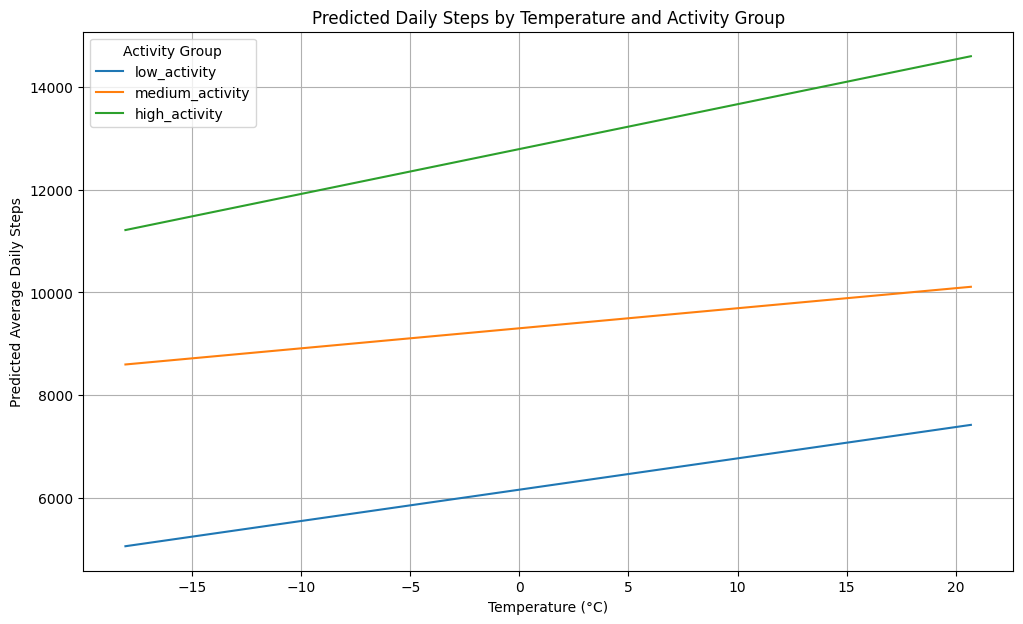

In [ ]:
plt.figure(figsize=(12, 7))

for group in prediction_data['activity_group'].unique():
    group_data = prediction_data[prediction_data['activity_group'] == group]
    plt.plot(
        group_data['temperature'],
        group_data['predicted_steps'],
        label=group
    )

plt.title('Predicted Daily Steps by Temperature and Activity Group')
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Average Daily Steps')
plt.legend(title='Activity Group')
plt.grid(True)
plt.show()

# Step 13D. Plotly Version of Regression Prediction

I also create an interactive Plotly version of the regression prediction graph so that it can be added to the project website if needed.

In [ ]:
import plotly.express as px

fig_regression = px.line(
    prediction_data,
    x='temperature',
    y='predicted_steps',
    color='activity_group',
    title='Regression Prediction: Temperature and Daily Steps by Activity Group',
    labels={
        'temperature': 'Temperature (°C)',
        'predicted_steps': 'Predicted Average Daily Steps',
        'activity_group': 'Activity Group'
    }
)

fig_regression.update_layout(
    autosize=True,
    height=600,
    title_font_size=18,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    legend_title_font_size=12,
    legend_font_size=11,
    margin=dict(l=60, r=30, t=80, b=60)
)

fig_regression.show()

In [ ]:
fig_regression.write_html(
    "regression_temperature_activity_group.html",
    config={"responsive": True}
)

In [ ]:
from google.colab import files

files.download("regression_temperature_activity_group.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 13E. Regression Interpretation

The regression model supports the visual pattern that warmer temperatures are associated with higher average daily steps. For the low-activity group, each 1°C increase in temperature is associated with about 61 additional predicted steps, holding precipitation and cloud cover constant.

The interaction terms suggest that the temperature relationship differs by activity group. The medium-activity group has a weaker temperature slope than the low-activity group, while the high-activity group has a stronger temperature slope. This means that high-activity participants appear to be more responsive to warmer weather.

The model also suggests that cloud cover is negatively associated with steps, while precipitation has a positive coefficient. However, the precipitation result should be interpreted cautiously because the earlier precipitation category graph showed very small differences between precipitation and no-precipitation days.

Overall, the regression adds support to the main finding: temperature is the clearest weather-related predictor of daily activity, but the results show association rather than causation.

# Conclusion!!

This project examined whether weather conditions affect daily productivity-related behavior, using physical activity as a proxy for daily behavior. After cleaning and merging the Norway wearable activity dataset with Open-Meteo weather data, I divided participants into low-, medium-, and high-activity groups based on their average daily steps.

The strongest pattern was between temperature and daily steps. Across all three activity groups, warmer temperatures were associated with higher average daily steps. The regression model with interaction terms also suggested that the relationship between temperature and steps differed across activity groups, with high-activity participants showing the strongest increase in predicted steps as temperature increased.

Precipitation did not show a strong visual relationship with activity, while very cloudy days were associated with slightly lower steps. Overall, temperature appeared to be the clearest weather-related factor in this analysis.

However, these results should be interpreted as associations, not proof of causation. The data is observational, activity is only a proxy for productivity, and seasonal patterns may influence both weather and physical activity. Even with these limitations, the project shows that weather, especially temperature, may be meaningfully related to daily activity behavior.

## Reflection

One thing that surprised me was that precipitation did not show as strong of a negative relationship with steps as I expected. I originally thought rainy days would clearly reduce activity, but the visualizations showed only small differences between precipitation and non-precipitation days.

The most challenging part of the project was making the two datasets compatible. The activity dataset was daily participant-level data, while the weather dataset was hourly time-based data. To merge them, I had to convert date formats, aggregate hourly weather into daily averages, group participants by activity level, and then merge both datasets by date.

If I had more time, I would add more personal productivity measures, such as study time, screen time, or sleep data. That would make the project closer to actual productivity instead of relying only on physical activity as a proxy.

## Resources and Credit

I used pandas, matplotlib, Plotly, and statsmodels documentation while building this project. I also used Gemini for limited help with debugging and understanding how to describe regression with interaction terms.
All analysis decisions, code adaptation, interpretation, and final writing were completed by me.